# A1 — granule subtypes and neuropil microdomains from Baysor / SSAM detections

Replicates mcDETECT's granule-level downstream chain on the assumption-light methods' detections:
subtyping → subtype density (WT vs AD) → neuropil microdomains → microdomain DE.

**`markers` setting only.** Under the `all`-genes setting the detections are not isolable granules
(they are whole-panel segments / KDE maxima), so subtyping them would not mean what it means for
mcDETECT. `A1_filter_de.ipynb` covers `all` for the filtering / DE / pathway comparison.

**Self-contained, but it consumes `A1_filter_de.ipynb`'s caches.** Populations, `brain_area` and the
registered WT/AD coordinates are read from `<config>_features.parquet` — nothing is recomputed here.
Run `A1_filter_de.ipynb` section 3 first.

**Spatial scaffold is mcDETECT's, unchanged.** SpaGCN layer labels, the 50 µm Isocortex spot grid,
the cell table and the cell × gene count matrix do not depend on which granule set is used, so this
notebook reuses `neuropil_subdomains_spots_ambient.h5ad` / `neuropil_subdomains_adata.h5ad` /
`count.parquet` verbatim and swaps in only the detections. That is what makes the comparison to
`code/7_neuropil_subdomains.ipynb` fair.

Set `METHOD` and `POPULATION` in the first cell and re-run the whole notebook for each combination.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.cluster import KMeans, MiniBatchKMeans

sys.path.insert(0, str(Path.cwd()))          # run this notebook from postproc/
import postproc_config as C
import sphere_features as SF
from mcDETECT.downstream import spot_embedding

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

# ================= knobs: re-run the notebook once per combination ================= #
METHOD = "baysor"          # "baysor" | "ssam"
POPULATION = "pop2"        # "pop1" (all detections) | "pop2" (out-of-nucleus)
GENESET = "markers"        # fixed -- subtyping is only meaningful in the markers setting

# Fixed at the published mcDETECT settings -- not swept.
# subtyping   : benchmark_subtyping.ipynb `main_result` (MiniBatchKMeans on the 34 REF_GENES)
# microdomains: neuropil_subdomains_Isocortex_50 (KMeans, n_init=20, seed 42)
K_SUBTYPE = C.K_SUBTYPE            # 15 subtype clusters
K_SUBDOMAIN = C.K_SUBDOMAIN        # 4 microdomains
SPOT_UM = 50                       # the mcDETECT spot scaffold reused here is 50 um
RANDOM_STATE = 42                  # microdomain KMeans / subsampling
# C.SUBTYPE_SEED (= 1) is the subtyping seed: SEED_LIST[0] of the published main_result arm
# which subdomains to contrast is set in section 6, after you have seen the map

OUT = C.subtype_dir(METHOD, POPULATION, GENESET)
OUT.mkdir(parents=True, exist_ok=True)

color_dct = ["#F56867", "#FEB915", "#C798EE", "#59BE86", "#7495D3", "#6D1A9C",
             "#15821E", "#3A84E6", "#997273", "#787878", "#DB4C6C", "#9E7A7A",
             "#554236", "#AF5F3C", "#93796C", "#F9BD3F", "#DAB370", "#877F6C", "#268785"]

print("method    :", METHOD, "| geneset:", GENESET, "| population:", POPULATION)
print("output    :", OUT)


/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-p

method    : baysor | geneset: markers | population: pop2
output    : /Users/chenyang/Desktop/mcDETECT/R2_revision/baysor_ssam_merscope/output/postproc/subtypes/baysor_markers_pop2


## 1. Load the detections (from `A1_filter_de.ipynb`'s cache)


In [2]:
parts = []
for sample in C.SAMPLES:
    f_path = C.features_path(METHOD, sample, GENESET)
    p_path = C.profile_path(METHOD, sample, GENESET)
    if not (f_path.exists() and p_path.exists()):
        raise FileNotFoundError(f"{f_path.name} / {p_path.name} missing -- run A1_filter_de.ipynb first.")

    feats = pd.read_parquet(f_path)
    missing = [c for c in [POPULATION, "brain_area", "global_x_adjusted", "global_y_adjusted"]
               if c not in feats.columns]
    if missing:
        raise KeyError(f"{f_path.name} lacks {missing} -- rerun A1_filter_de.ipynb section 3, "
                       f"which writes the population flags and annotation back into this file.")

    adata = anndata.read_h5ad(p_path)
    for col in [POPULATION, "brain_area", "global_x_adjusted", "global_y_adjusted"]:
        adata.obs[col] = feats[col].to_numpy()

    sub = adata[adata.obs[POPULATION].to_numpy()].copy()
    sub.obs["batch"] = C.dataset_name(sample)      # MERSCOPE_WT_1 / MERSCOPE_AD_1, as mcDETECT labels it
    sub.obs["sample"] = sample
    # coordinates the microdomain pipeline expects (5_neuropil_subdomains_data.py:200-206)
    gx, gy = SF.subdomain_coords(sub.obs, sample)
    sub.obs["global_x"] = gx
    sub.obs["global_y"] = gy
    print(f"[{sample}] {adata.n_obs:,} detections -> {sub.n_obs:,} in {POPULATION}")
    parts.append(sub)

granule_adata = anndata.concat(parts, index_unique="-")
granule_adata.obs["granule_id"] = [f"gnl_{i}" for i in range(granule_adata.n_obs)]
del parts
granule_adata


[WT] 1,083,376 detections -> 632,039 in pop2
[AD] 687,274 detections -> 375,313 in pop2


AnnData object with n_obs × n_vars = 1007352 × 290
    obs: 'sphere_x', 'sphere_y', 'sphere_z', 'layer_z', 'sphere_r', 'n_total', 'n_in_nucleus', 'n_marker', 'n_marker_in_nucleus', 'n_nc', 'comp', 'in_soma_ratio_all', 'in_soma_ratio_marker', 'marker_frac', 'nc_ratio_all', 'nc_ratio_marker', 'cell_id', 'n_molecules', 'method', 'sample', 'geneset', 'pop2', 'brain_area', 'global_x_adjusted', 'global_y_adjusted', 'batch', 'global_x', 'global_y', 'granule_id'
    layers: 'counts'

## 2. Clustering — mcDETECT's subtyping procedure, matched exactly

From `code/benchmark/benchmark_subtyping.ipynb` (the `main_result` arm, which produced the published
`granule_subtype_kmeans` labels; identical in `code/old/8_neuropil_subdomains_pair2.py:190-210`):

1. `normalize_total(1e4)` → `log1p` on the **full 290-gene panel** (as `3_detection.py:114-115` does;
   the benchmark reads that already-normalized object and only then subsets);
2. subset to **`C.REF_GENES` — 34 compartment markers**, a superset of the 20 `syn_genes` used for
   *detection* that adds post-synaptic / dendritic / axonal genes which seed nothing but do
   discriminate compartments;
3. densify and run **`MiniBatchKMeans(n_clusters=15, batch_size=5000, random_state=1, n_init=20)`**
   on that marker matrix.

No PCA and no plain `KMeans` anywhere in that chain — clustering is on the marker genes themselves.
mcDETECT's t-SNE is also not reproduced: nothing downstream reads it, and on 10⁵–10⁶ detections it
would be the slowest step in the notebook for a panel no output depends on.


In [3]:
# normalize on the full panel first (3_detection.py:114-115), then subset -- this order matters
granule_adata.layers["counts"] = granule_adata.X.copy()
sc.pp.normalize_total(granule_adata, target_sum=1e4)
sc.pp.log1p(granule_adata)

ref_genes_present = [g for g in C.REF_GENES if g in granule_adata.var_names]
print(f"clustering on {len(ref_genes_present)}/{len(C.REF_GENES)} REF_GENES present in the panel")
missing_ref = sorted(set(C.REF_GENES) - set(ref_genes_present))
if missing_ref:
    print("  not in panel:", missing_ref)

sub = granule_adata[:, ref_genes_present].copy()
X_sub = sub.X.toarray() if hasattr(sub.X, "toarray") else np.asarray(sub.X)

np.random.seed(C.SUBTYPE_SEED)
km = MiniBatchKMeans(n_clusters=K_SUBTYPE, batch_size=C.KMEANS_BATCH_SIZE,
                     random_state=C.SUBTYPE_SEED, n_init=C.KMEANS_N_INIT)
km.fit(X_sub)

cats = [str(i) for i in range(K_SUBTYPE)]
granule_adata.obs["granule_subtype_kmeans"] = pd.Categorical(
    km.labels_.astype(str), categories=cats, ordered=True)
sub.obs["granule_subtype_kmeans"] = granule_adata.obs["granule_subtype_kmeans"].values

print(granule_adata.obs["granule_subtype_kmeans"].value_counts().sort_index())


clustering on 34/34 REF_GENES present in the panel
granule_subtype_kmeans
0     56874
1     62845
2     53388
3     63235
4     75493
5     87456
6     73379
7     65753
8     52543
9     79383
10    47411
11    81730
12    55915
13    75382
14    76565
Name: count, dtype: int64


## 3. Marker heatmap → **manual subtyping**

The cluster × marker heatmap is what you read to assign each KMeans cluster to a compartment. Same
call as `benchmark_subtyping.ipynb` cell 22: `sc.pl.heatmap` over `REF_GENES`, grouped by cluster,
`cmap="Reds"`, `standard_scale="var"`, `swap_axes=True`, no dendrogram — so it is directly
comparable to mcDETECT's `heatmap_subtype.jpeg`.

As in mcDETECT, the mapping is filled in by hand from this heatmap — no automatic classifier is run.


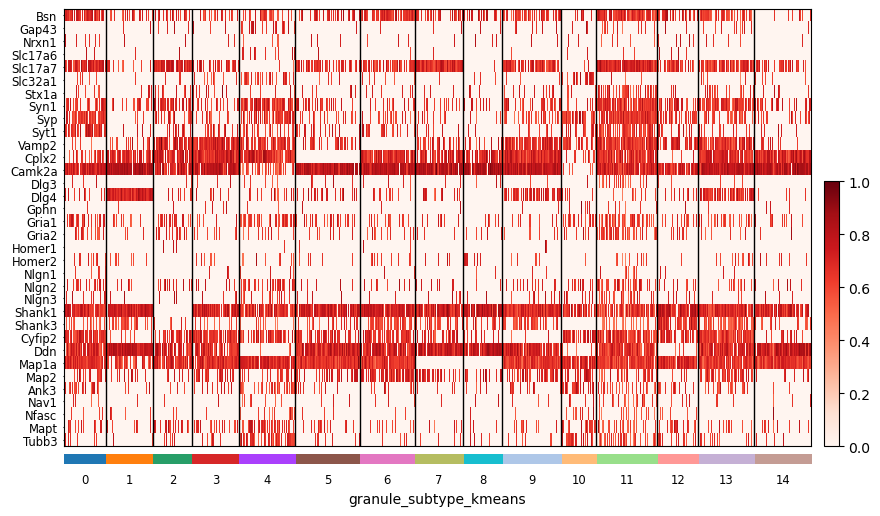

granule_subtype_kmeans
0     56874
1     62845
2     53388
3     63235
4     75493
5     87456
6     73379
7     65753
8     52543
9     79383
10    47411
11    81730
12    55915
13    75382
14    76565
Name: n, dtype: int64

In [4]:
# ---- heatmap, exactly as benchmark_subtyping.ipynb cell 22 ---- #
ax = sc.pl.heatmap(sub, var_names=ref_genes_present, groupby="granule_subtype_kmeans",
                   cmap="Reds", standard_scale="var", dendrogram=False, swap_axes=True,
                   show=False, figsize=(10, 6))
plt.gcf().savefig(OUT / "heatmap_subtype.jpeg", dpi=500, bbox_inches="tight")
plt.show()

# cluster x marker means, as a table to read alongside the heatmap
cluster_mean = (pd.DataFrame(X_sub, columns=ref_genes_present)
                .assign(cluster=granule_adata.obs["granule_subtype_kmeans"].to_numpy())
                .groupby("cluster", observed=True).mean())
cluster_mean.to_csv(OUT / "subtype_marker_means.csv")

granule_adata.obs["granule_subtype_kmeans"].value_counts().sort_index().rename("n")


### Manual mapping — **fill this in from the heatmap above**

mcDETECT's format (`benchmark_subtyping.ipynb::apply_manual_annotation`,
`code/old/8_neuropil_subdomains_pair2.py:85`): a dict of **subtype → list of cluster ids**, where
keys joined with `" & "` denote clusters expressing more than one compartment. Those combination
keys collapse to `"mixed"` in `granule_subtype_manual_simple`; clusters left unlisted stay
unannotated (NaN), which is allowed.

The template below starts empty, exactly like mcDETECT's placeholder. On the **first pass** leave it
empty and just read the heatmap; the notebook still runs end to end (subtype density is simply empty,
and the microdomain sections do not depend on the mapping). Then fill it in and re-run from here.


In [ ]:
# EDIT ME -- subtype -> [cluster ids], read off heatmap_subtype.jpeg above.
# Keys containing " & " collapse to "mixed" in *_manual_simple; unlisted clusters stay NaN.
MANUAL_SUBTYPE_MAPPING = {
    "pre-syn": [],
    "post-syn": [],
    "dendrites": [],
    "axons": [],
    "pre & post": [],
    "pre & den": [],
    "post & den": [],
    "pre & post & den": [],
    "others": [],
}

# ---- apply, as benchmark_subtyping.ipynb::apply_manual_annotation ---- #
k2sub = {c: subtype for subtype, clusters in MANUAL_SUBTYPE_MAPPING.items() for c in clusters}
granule_adata.obs["granule_subtype_manual"] = (
    granule_adata.obs["granule_subtype_kmeans"].astype(str).map(k2sub))
granule_adata.obs["granule_subtype_manual_simple"] = pd.Categorical(
    granule_adata.obs["granule_subtype_manual"].apply(
        lambda s: "mixed" if pd.notna(s) and " & " in str(s) else s),
    categories=C.SUBTYPE_NAMES, ordered=True).remove_unused_categories()
granule_adata.obs["granule_subtype"] = granule_adata.obs["granule_subtype_manual_simple"]

n_unassigned = int(granule_adata.obs["granule_subtype_manual_simple"].isna().sum())
if n_unassigned:
    print(f"note: {n_unassigned:,} detections in clusters left out of the mapping (subtype = NaN)")

# Save in mcDETECT's label schema (matches granule_subtype_labels_granule_adata_tsne.parquet)
labels = granule_adata.obs[["batch", "granule_id", "granule_subtype_kmeans",
                            "granule_subtype_manual", "granule_subtype_manual_simple",
                            "global_x", "global_y"]].copy()
labels = labels.rename(columns={"batch": "sample"})
labels.to_parquet(OUT / "granule_subtype_labels.parquet", index=False)

granule_adata.obs["granule_subtype_manual_simple"].value_counts(dropna=False)


## 4. Granule-subtype density, WT vs AD — matched to mcDETECT

Reproduces mcDETECT's published subtype-density analysis
(`code/benchmark/benchmark_subtyping.ipynb` cell 22) on these detections, so the two are directly
comparable:

* density per `(brain_area, subtype)` = detections in that area / spots in that area, on the
  sample's **own** 50 µm spot grid, plus an `overall` row per area;
* **AD is divided by `CAPTURE_EFFICIENCY_COEF = 0.818691`** — i.e. scaled up ~22% — applied to the
  per-spot counts so density, sd, sem, CI and the test all inherit it;
* per-spot `density_sd` / `density_sem` and a 500-resample bootstrap 95% CI;
* WT-vs-AD `ttest_ind` on `log1p` per-spot counts, Bonferroni **within subtype** plus BH-FDR, and
  the star strings from `mcDETECT.utils.p_val_to_star`.

The output columns match `subtype_density_per_region_granule_adata_tsne.csv` exactly, so the bar
plots are drawn by `A1_figures.R` section 4 with the same code path as mcDETECT's figure — this cell
only prepares data.

**Coordinates:** `sphere_x` / `sphere_y`, each sample's own raw frame, against that sample's own
`spots.h5ad`. Not `global_x` / `global_y` — on this object those hold the registered microdomain
frame, which would silently overlay detections on the wrong spot grid.

Counting uses `SF.grid_counts`, a vectorised equivalent of mcDETECT's per-spot square test (its loop
rescans the whole detection table once per spot, which is O(10⁴ × 10⁶) here and repeats per subtype).


In [ ]:
density_parts, per_spot_parts, neuron_rows = [], [], []

for sample in C.SAMPLES:
    spots = sc.read_h5ad(C.spots_path(sample))
    obs = granule_adata.obs
    mask = (obs["sample"] == sample).to_numpy()

    dens, per_spot = SF.subtype_density_per_region(
        det_x=obs.loc[mask, "sphere_x"].to_numpy(),
        det_y=obs.loc[mask, "sphere_y"].to_numpy(),
        det_subtype=obs.loc[mask, "granule_subtype_manual_simple"].to_numpy(),
        spots=spots,
        sample=sample,
        apply_capture_coef=(sample == "AD"),   # mcDETECT divides AD by CAPTURE_EFFICIENCY_COEF
        grid_len=SPOT_UM,
    )
    density_parts.append(dens)
    per_spot_parts.append(per_spot)

    # neuron density, for context. NOT capture-corrected: the coefficient is about transcript
    # capture, and these are segmented cells.
    cells = sc.read_h5ad(C.cells_path(sample))
    neurons = cells[cells.obs["cell_type"].isin(["Glutamatergic", "GABAergic"])]
    neu_count = SF.grid_counts(neurons.obs["global_x"].to_numpy(),
                               neurons.obs["global_y"].to_numpy(), spots, grid_len=SPOT_UM)
    area = np.asarray(spots.obs["brain_area"])
    for a in C.AREA_LIST:
        sel = area == a
        if sel.sum():
            neuron_rows.append({"sample": sample, "brain_area": a, "n_spots": int(sel.sum()),
                                "neuron_density": float(neu_count[sel].mean())})
    del spots, cells, neurons

density_df = SF.add_density_significance(
    pd.concat(density_parts, ignore_index=True),
    pd.concat(per_spot_parts, ignore_index=True),
    setting=f"{METHOD}_{GENESET}_{POPULATION}",
)
density_df.to_csv(OUT / "subtype_density_per_region.csv", index=False)
pd.DataFrame(neuron_rows).to_csv(OUT / "neuron_density_per_region.csv", index=False)
print(f"wrote subtype_density_per_region.csv ({density_df.shape[0]} rows) and "
      f"neuron_density_per_region.csv")

# sanity: 'overall' should equal the sum of the subtype rows wherever every detection is labelled
chk = (density_df[density_df["brain_area"].isin(C.AREA_LIST)]
       .assign(kind=lambda d: np.where(d["subtype"] == "overall", "overall", "subtypes"))
       .groupby(["sample", "brain_area", "kind"])["density"].sum().unstack())
n_unlabelled = int(granule_adata.obs["granule_subtype_manual_simple"].isna().sum())
print(f"unlabelled detections: {n_unlabelled:,}"
      f"{' -- subtypes will sum below overall by design' if n_unlabelled else ''}")

(density_df[density_df["brain_area"].isin(C.AREA_LIST)]
 .pivot_table(index=["subtype", "brain_area"], columns="sample", values="density")
 .round(4))


## 5. Neuropil microdomains

Reuses mcDETECT's spatial scaffold verbatim — `neuropil_subdomains_spots_ambient.h5ad` (4,310 spots,
50 µm, Isocortex, with SpaGCN `layer_labels`), `neuropil_subdomains_adata.h5ad` and the concatenated
`count.parquet` — and swaps in only this method's detections, so any difference in the microdomains
is attributable to the detections rather than to the scaffold. Call signature follows
`code/7_neuropil_subdomains.ipynb` cell 9 (the "hard" embedding branch).


In [ ]:
spots = sc.read_h5ad(C.SUBDOMAIN_SPOTS_50)
adata_cells = sc.read_h5ad(C.SUBDOMAIN_ADATA)
adata_neuron = adata_cells[adata_cells.obs["cell_type"].isin(["Glutamatergic", "GABAergic"])].copy()

count_matrix = pd.concat([pd.read_parquet(C.count_matrix_path(s)) for s in C.SAMPLES],
                         axis=0, ignore_index=True)
count_matrix["cell_id"] = count_matrix["cell_id"].astype(str)
count_matrix = (count_matrix.set_index("cell_id")
                .reindex(columns=list(granule_adata.var_names), fill_value=0).reset_index())
assert count_matrix.columns[1:].tolist() == granule_adata.var_names.tolist()

print("spots:", spots.shape, "| neurons:", adata_neuron.shape, "| detections:", granule_adata.shape)


In [ ]:
subtype_names = sorted(granule_adata.obs["granule_subtype_kmeans"].unique(), key=int)

embeddings, embeddings_features, aux_features, spot_granule_expression, spot_cell_expression = \
    spot_embedding(
        spots=spots,
        granule_adata=granule_adata,
        adata=adata_neuron,
        count_matrix=count_matrix,
        spot_loc_key=("global_x", "global_y"),
        spot_width=SPOT_UM,
        spot_height=SPOT_UM,
        granule_loc_key=("global_x", "global_y"),
        granule_subtype_key="granule_subtype_kmeans",
        subtype_names=[str(x) for x in subtype_names],
        granule_count_layer="counts",
        cell_loc_key=("global_x", "global_y"),
        cell_id_key="cell_id",
        count_matrix_cell_id_key="cell_id",
        include_soma_features=True,
        smoothing=True,
        smoothing_radius=np.sqrt(2) * SPOT_UM + 1,
        smoothing_mode="gaussian",
    )

for key, val in aux_features.items():
    spots.obs[key] = val

spot_ambient_expression = np.maximum(
    spots.layers["extrasomatic_transcripts"] - spot_granule_expression, 0)

# Drop spots with no detections, as 7_neuropil_subdomains.ipynb does before clustering
# (it subsets spots / embeddings / expressions by the same mask rather than labelling them).
mask = np.asarray(spots.obs["granule_count"]) > 0
print(f"{mask.sum():,}/{spots.n_obs:,} spots contain at least one detection -- keeping those")
spots = spots[mask].copy()
embeddings = embeddings[mask].copy()
spot_granule_expression = spot_granule_expression[mask].copy()
spot_cell_expression = spot_cell_expression[mask].copy()
spot_ambient_expression = spot_ambient_expression[mask].copy()

print("embeddings:", embeddings.shape,
      "| mean detections/spot:", round(float(np.nanmean(spots.obs["granule_count"])), 2))


In [ ]:
# Microdomains = KMeans over the subtype-composition embedding.
# mcDETECT clusters the ROW-NORMALIZED embedding, i.e. each spot's subtype *proportions* -- that is
# the "normalized" in its 4_hard_normalized_cluster_labels.parquet (7_neuropil_subdomains.ipynb;
# its "unnormalized" branch is skipped). Without this, spots would cluster by detection count.
row_sums = embeddings.sum(axis=1, keepdims=True)
X_spot = np.divide(embeddings, row_sums, out=np.zeros_like(embeddings, dtype=float),
                   where=row_sums > 0)

# plain KMeans with n_init=20, as 7_neuropil_subdomains.ipynb / 8_..._pair2.py:290.
# (mcDETECT then applied a hand-picked relabel_map to reorder its subdomain numbers; that mapping is
# specific to its run, so our "Subdomain k" numbering will not correspond to theirs -- which is why
# the pair to contrast is chosen by eye in section 6.)
km_sub = KMeans(n_clusters=K_SUBDOMAIN, random_state=RANDOM_STATE, n_init=20)
labels_sub = [f"Subdomain {i + 1}" for i in km_sub.fit_predict(X_spot)]
spots.obs["subdomain_kmeans"] = pd.Categorical(
    labels_sub, categories=[f"Subdomain {i + 1}" for i in range(K_SUBDOMAIN)], ordered=True)

spots.obs[["spot_id", "global_x", "global_y", "batch", "layer_labels",
           "subdomain_kmeans", "granule_count"]].to_parquet(
    OUT / f"{K_SUBDOMAIN}_hard_normalized_cluster_labels.parquet", index=False)

sc.set_figure_params(scanpy=True, figsize=(12.5, 5.5))
ax = sc.pl.scatter(spots, x="global_x", y="global_y", color="subdomain_kmeans",
                   palette=color_dct, size=80, title=" ", show=False)
ax.grid(False); ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(""); ax.set_ylabel("")
plt.savefig(OUT / "subdomains.jpeg", dpi=300, bbox_inches="tight")
plt.show()

# layer composition (input for the alluvial plot in figures_response.Rmd)
comp = (spots.obs.groupby(["subdomain_kmeans", "layer_labels"]).size()
        .rename("n").reset_index())
comp.to_csv(OUT / "subdomain_layer_composition.csv", index=False)
pd.crosstab(spots.obs["subdomain_kmeans"], spots.obs["layer_labels"], normalize="index").round(3)


## 6. Microdomain DE

**Set the pair(s) below after looking at the subdomain map and layer composition above** — which two
microdomains are worth contrasting is a judgement call, not something to hard-code. You can list
several pairs; each produces its own set of CSVs, and `A1_figures.R` discovers all of them
automatically, so no path or name has to be repeated on the R side.

To try another pair later, edit `SUBDOMAIN_PAIRS` and re-run just the next two cells.


In [ ]:
# EDIT ME -- (target, reference) pairs to contrast. Pre-filled with the two largest subdomains.
_sizes = spots.obs["subdomain_kmeans"].value_counts()
SUBDOMAIN_PAIRS = [(str(_sizes.index[0]), str(_sizes.index[1]))]

print("subdomain sizes (spots):")
print(_sizes.to_string())
print("\npairs to test:", SUBDOMAIN_PAIRS)


In [ ]:
obs_sel = spots.obs.copy()
present = set(obs_sel["subdomain_kmeans"].astype(str))

# normalize once per expression layer, then run every pair against it
layers = {}
for expression, label in [(spot_granule_expression, "granule"),
                          (spot_cell_expression, "cell"),
                          (spot_ambient_expression, "ambient")]:
    ad_expr = anndata.AnnData(X=np.asarray(expression).copy(), obs=obs_sel.copy(),
                              var=granule_adata.var.copy())
    ad_expr.obs_names = spots.obs_names
    sc.pp.normalize_total(ad_expr, target_sum=1e4)
    sc.pp.log1p(ad_expr)
    layers[label] = ad_expr

de_micro = {}
for target, reference in SUBDOMAIN_PAIRS:
    if not {target, reference} <= present:
        print(f"[{target} vs {reference}] not both present in subdomain_kmeans -- skipped")
        continue
    for label, ad_expr in layers.items():
        sc.tl.rank_genes_groups(ad_expr, groupby="subdomain_kmeans", groups=[target],
                                reference=reference, method="wilcoxon")
        df = (sc.get.rank_genes_groups_df(ad_expr, group=target)
              .sort_values("logfoldchanges", ascending=False))
        # filename matches code/7_neuropil_subdomains.ipynb so the R GSEA/chord step finds it
        out_path = OUT / f"{label}_DE_genes_{target}_vs_{reference}.csv"
        df.to_csv(out_path, index=False)
        de_micro[(label, target, reference)] = df
        print(f"[{label}] wrote {out_path.name}  ({df.shape[0]} genes)")

next(iter(de_micro.values()), pd.DataFrame()).head(15)


## Outputs

All under `../output/postproc/subtypes/<method>_markers_<population>/`:

| file | contents |
|---|---|
| `heatmap_subtype.jpeg`, `subtype_marker_means.csv` | the heatmap you subtype from (same call as mcDETECT's) |
| `granule_subtype_labels.parquet` | cluster → compartment labels, mcDETECT's schema |
| `subtype_density_per_region.csv` | WT/AD subtype density, mcDETECT's schema (capture-corrected, with CIs + stars) — plotted by `A1_figures.R` section 5 |
| `neuron_density_per_region.csv` | neuron density per region, for context |
| `<K>_hard_normalized_cluster_labels.parquet`, `subdomains.jpeg`, `subdomain_layer_composition.csv` | neuropil microdomains |
| `{granule,cell,ambient}_DE_genes_<target>_vs_<reference>.csv` | microdomain DE, one set per pair in `SUBDOMAIN_PAIRS` |

Then run `A1_figures.R` (section 6): it discovers every DE table written here and produces the GSEA
tables, NES dotplots and chord diagrams alongside them, in the same layout as
`output/MERSCOPE_WT_AD_comparison/neuropil_subdomains_Isocortex_50/`.

**Relationship to `A1_filter_de.ipynb` section 6.** Both write microdomain DE tables into the same
run directories and both are picked up by `A1_figures.R` section 6; they answer different questions
and are meant to coexist. This notebook recomputes the microdomains from each method's *own*
subtypes, which is the honest test of whether a method can build a microdomain map at all — but it
needs `MANUAL_SUBTYPE_MAPPING` filled in first, and it cannot produce a result when the subtypes come
out highly mixed. `A1_filter_de.ipynb` section 6 instead *inherits* mcDETECT's published
microdomains and swaps in only the expression, which always yields a table and isolates the
question to whether the aggregated transcripts carry the granule-layer contrast.

Re-run this notebook with the other `METHOD` / `POPULATION` values to fill in the remaining arms
(baysor/ssam × pop1/pop2).

**Methodology matched to mcDETECT, not swept.** Subtyping: `MiniBatchKMeans(15, batch_size=5000,
n_init=20, random_state=1)` on the **34 `REF_GENES`** after full-panel normalisation — no PCA, no
plain KMeans (`code/benchmark/benchmark_subtyping.ipynb`, `main_result` arm). Microdomains:
`KMeans(4, n_init=20, random_state=42)`, ROI = Isocortex, 50 µm spots. SpaGCN layer labels and the
spot grid are read from
`neuropil_subdomains_spots_ambient.h5ad`, never recomputed. `subdomain_kmeans` *is* recomputed per
method, because microdomains are defined by granule-subtype composition and must follow each
method's own detections — inheriting mcDETECT's labels would make the comparison circular.
